In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

<h2><u>Exploratory Analysis</u></h2>

In [56]:
data = pd.read_csv('bestsellers with categories.csv')
data.head(20)

# The same book appears in multiple rows
# We might want to make a new dataset that groups them together on name/author/genre.

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
5,A Dance with Dragons (A Song of Ice and Fire),George R. R. Martin,4.4,12643,11,2011,Fiction
6,A Game of Thrones / A Clash of Kings / A Storm...,George R. R. Martin,4.7,19735,30,2014,Fiction
7,A Gentleman in Moscow: A Novel,Amor Towles,4.7,19699,15,2017,Fiction
8,"A Higher Loyalty: Truth, Lies, and Leadership",James Comey,4.7,5983,3,2018,Non Fiction
9,A Man Called Ove: A Novel,Fredrik Backman,4.6,23848,8,2016,Fiction


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550 entries, 0 to 549
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         550 non-null    object 
 1   Author       550 non-null    object 
 2   User Rating  550 non-null    float64
 3   Reviews      550 non-null    int64  
 4   Price        550 non-null    int64  
 5   Year         550 non-null    int64  
 6   Genre        550 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 30.2+ KB


In [10]:
data.describe()

,User Rating,Reviews,Price,Year
count,550.000000,550.000000,550.000000,550.000000
mean,4.618364,11953.281818,13.100000,2014.000000
std,0.226980,11731.132017,10.842262,3.165156
min,3.300000,37.000000,0.000000,2009.000000
25%,4.500000,4058.000000,7.000000,2011.000000
50%,4.700000,8580.000000,11.000000,2014.000000
75%,4.800000,17253.250000,16.000000,2017.000000
max,4.900000,87841.000000,105.000000,2019.000000


In [17]:
data['Genre'].value_counts()

Non Fiction    310
Fiction        240
Name: Genre, dtype: int64

In [19]:
data['Genre'].value_counts(normalize=True)

Non Fiction    0.563636
Fiction        0.436364
Name: Genre, dtype: float64

In [23]:
# Creates a dataset where the book has been reviewed >=2500 times
# Groups by Name/Author/Genre and gives the mean of user ratings as well as average rating
# Cuts down row count from 550 to 287

data_2500_reviews = data.groupby(['Name', 'Author', 'Genre'], as_index=False)[['User Rating', 'Reviews']].mean()
data_2500_reviews = data_2500_reviews[data_2500_reviews['Reviews'] > 2500]
data_2500_reviews = data_2500_reviews.sort_values('User Rating', ascending=False)
data_2500_reviews

,Name,Author,Genre,User Rating,Reviews
69,Dog Man: Fetch-22: From the Creator of Captain...,Dav Pilkey,Fiction,4.9,12619.0
330,Unfreedom of the Press,Mark R. Levin,Non Fiction,4.9,5956.0
66,Dog Man and Cat Kid: From the Creator of Capta...,Dav Pilkey,Fiction,4.9,5062.0
36,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,Fiction,4.9,14344.0
208,Strange Planet (Strange Planet Series),Nathan W. Pyle,Fiction,4.9,9382.0
...,...,...,...,...,...
251,The Goldfinch: A Novel (Pulitzer Prize for Fic...,Donna Tartt,Fiction,3.9,33844.0
20,Allegiant,Veronica Roth,Fiction,3.9,6310.0
88,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,Fiction,3.8,47265.0
101,Go Set a Watchman: A Novel,Harper Lee,Fiction,3.6,14982.0


<h2><u>Weighted Rating Analysis for User Reviews</u></h2>

The range of user reviews for books can vary greatly in this case. Some books have less than 5000 reviews, while others have over 25,000.

A good way to measure user rating based on the number of ratings is assigning the book a weighted rating.

For calculating weighted rating, we can use the formula:

**weighted rating = (WR) = (v/(v+m)) * R + (m/(v+m)) * C**

R = average rating for the book

v = number of ratings

m = minimum number of ratings to be in the 50 best-seller list on Amazon

C = mean rating of the dataset

In [27]:
# Setting up weighted rating

m = min(data['Reviews'])
C = data['User Rating'].mean()

def weighted_rating(x, m=m, C=C):
    v = x['Reviews']
    R = x['User Rating']
    return (v/(v+m) * R) + (m/(m+v) * C)

In [76]:
data['Weighted Rating'] = data.apply(weighted_rating, axis=1)

ratings = data.groupby(['Name', 'Author', 'Genre'], as_index=False)[['User Rating', 'Reviews', 'Weighted Rating']].mean().sort_values(by='Weighted Rating', ascending=False)
ratings

,Name,Author,Genre,User Rating,Reviews,Weighted Rating
178,"Oh, the Places You'll Go!",Dr. Seuss,Fiction,4.9,21834.0,4.899524
116,Harry Potter and the Chamber of Secrets: The I...,J.K. Rowling,Fiction,4.9,19622.0,4.899470
140,Jesus Calling: Enjoying Peace in His Presence ...,Sarah Young,Non Fiction,4.9,19576.0,4.899469
310,The Very Hungry Caterpillar,Eric Carle,Fiction,4.9,19546.0,4.899468
36,"Brown Bear, Brown Bear, What Do You See?",Bill Martin Jr.,Fiction,4.9,14344.0,4.899275
...,...,...,...,...,...,...
20,Allegiant,Veronica Roth,Fiction,3.9,6310.0,3.904188
251,The Goldfinch: A Novel (Pulitzer Prize for Fic...,Donna Tartt,Fiction,3.9,33844.0,3.900784
88,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,Fiction,3.8,47265.0,3.800640
101,Go Set a Watchman: A Novel,Harper Lee,Fiction,3.6,14982.0,3.602509


In [47]:
ratings.to_csv('Amazon Book Ratings.csv')

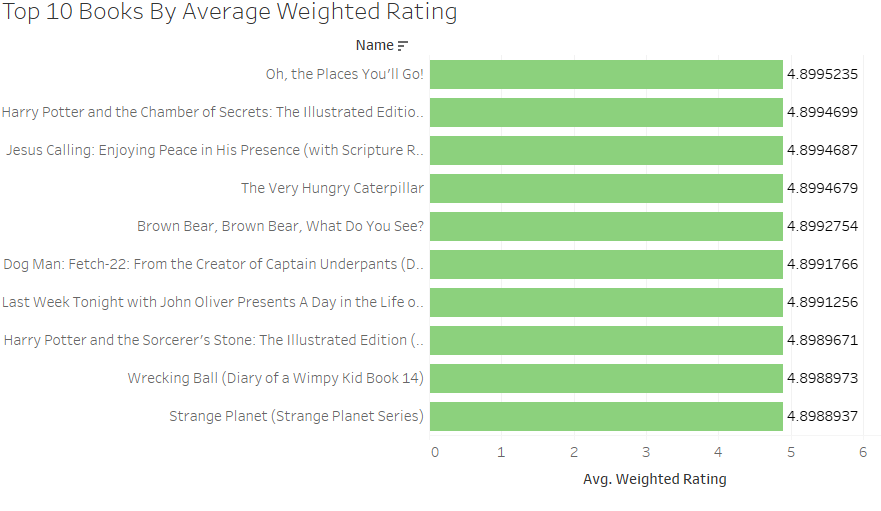

Dr. Seuss's *Oh The Places You'll Go!* comes out as the top-rated book sold, with a slight edge. The book was rated 21,834 times.

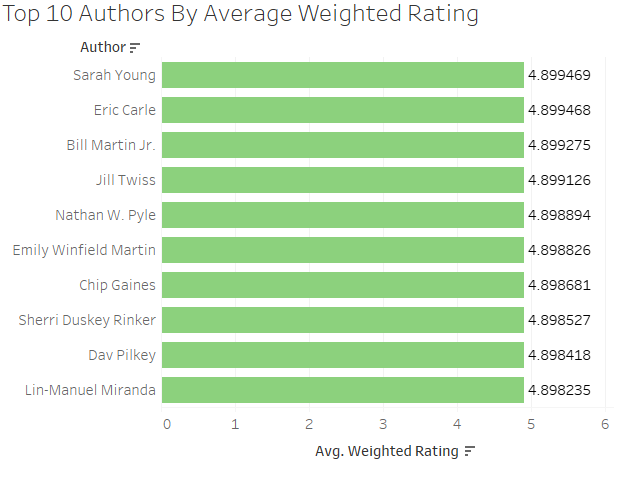

Sarah Young, with her book *Jesus Calling: Enjoying Peace with His Presence* helped her earn the spot of being the highest-rated author on Amazon. Her book received 19,576 reviews.

In [50]:
ratings.groupby(['Genre'])['Weighted Rating'].mean()

Genre
Fiction        4.615556
Non Fiction    4.604290
Name: Weighted Rating, dtype: float64

<h2><u>Book Price Analysis</u></h2>

In this section, we'll create some analytics about the books' prices.

In [62]:
prices = data.groupby(['Name', 'Author', 'Genre'], as_index=False)['Price'].mean().sort_values('Price', ascending=False)
prices.head(10)

,Name,Author,Genre,Price
56,Diagnostic and Statistical Manual of Mental Di...,American Psychiatric Association,Non Fiction,105.0
307,The Twilight Saga Collection,Stephenie Meyer,Fiction,82.0
112,Hamilton: The Revolution,Lin-Manuel Miranda,Non Fiction,54.0
228,The Book of Basketball: The NBA According to T...,Bill Simmons,Non Fiction,53.0
115,Harry Potter Paperback Box Set (Books 1-7),J. K. Rowling,Fiction,52.0
191,Publication Manual of the American Psychologic...,American Psychological Association,Non Fiction,46.0
333,Watchmen,Alan Moore,Fiction,42.0
281,The Official SAT Study Guide,The College Board,Non Fiction,40.0
220,The Alchemist,Paulo Coelho,Fiction,39.0
282,"The Official SAT Study Guide, 2016 Edition (Of...",The College Board,Non Fiction,36.0


The top 10 most expensive books include 6 non-fiction, which includes instructional or educational textbooks. The price could be explained by high page counts meaning a costlier book to produce.

In [61]:
prices.to_csv('book_prices.csv')

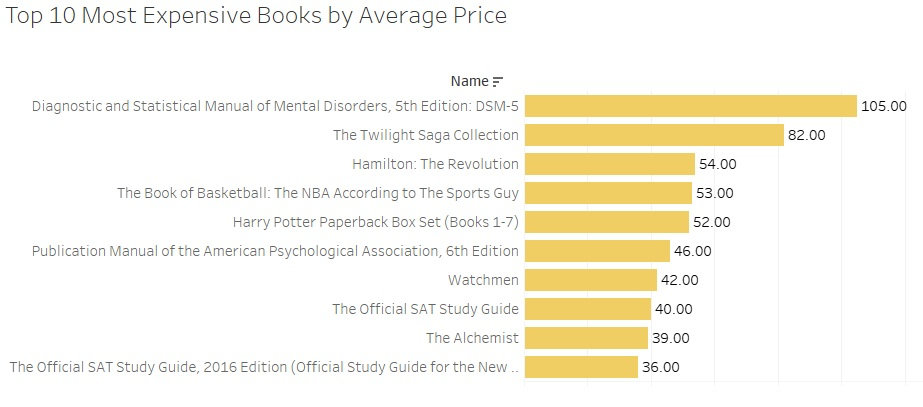

The most expensive book is the DSM-V by the American Psychological Association. It's over twice the cost of its newer addition, the DSM-VI (5th most expensive book).

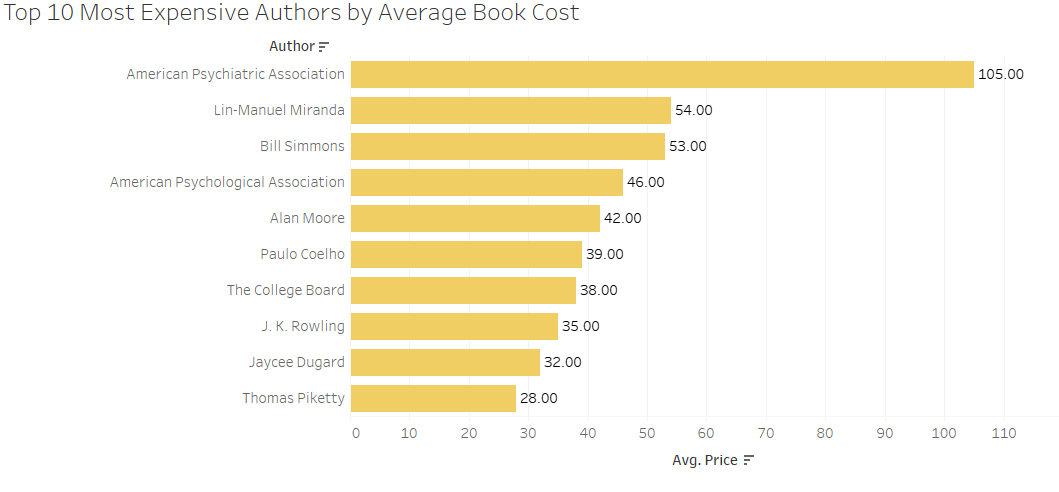

The American Psychiatric Association is the most expensive author by book. Since their publications are instructional texts meant for medical professionals, the cost associated with this kind of expertise in a book tends to run quite high. 

In [64]:
data.groupby(['Genre'], as_index=False)['Price'].mean()

,Genre,Price
0,Fiction,10.850000
1,Non Fiction,14.841935


<h2><u>Reviews Analysis</u></h2>

Non-Fiction tends to be more expensive than fiction. Textbooks, academic texts, study guides, books with high-quality photography, etc. fall under non-fiction. 

In [73]:
reviews = ratings.groupby(['Name', 'Author', 'Genre'], as_index=False)[['Weighted Rating', 'Reviews']].mean().sort_values('Reviews', ascending=False)
reviews.head(10)

,Name,Author,Genre,Weighted Rating,Reviews
342,Where the Crawdads Sing,Delia Owens,Fiction,4.799924,87841.0
248,The Girl on the Train,Paula Hawkins,Fiction,4.100241,79446.0
30,Becoming,Michelle Obama,Non Fiction,4.799890,61133.0
104,Gone Girl,Gillian Flynn,Fiction,4.000399,57271.0
240,The Fault in Our Stars,John Green,Fiction,4.699940,50482.0
280,The Nightingale: A Novel,Kristin Hannah,Fiction,4.799864,49288.0
88,Fifty Shades of Grey: Book One of the Fifty Sh...,E L James,Fiction,3.800640,47265.0
276,The Martian,Andy Weir,Fiction,4.699924,39459.0
19,All the Light We Cannot See,Anthony Doerr,Fiction,4.600019,36348.0
220,The Alchemist,Paulo Coelho,Fiction,4.699916,35799.0


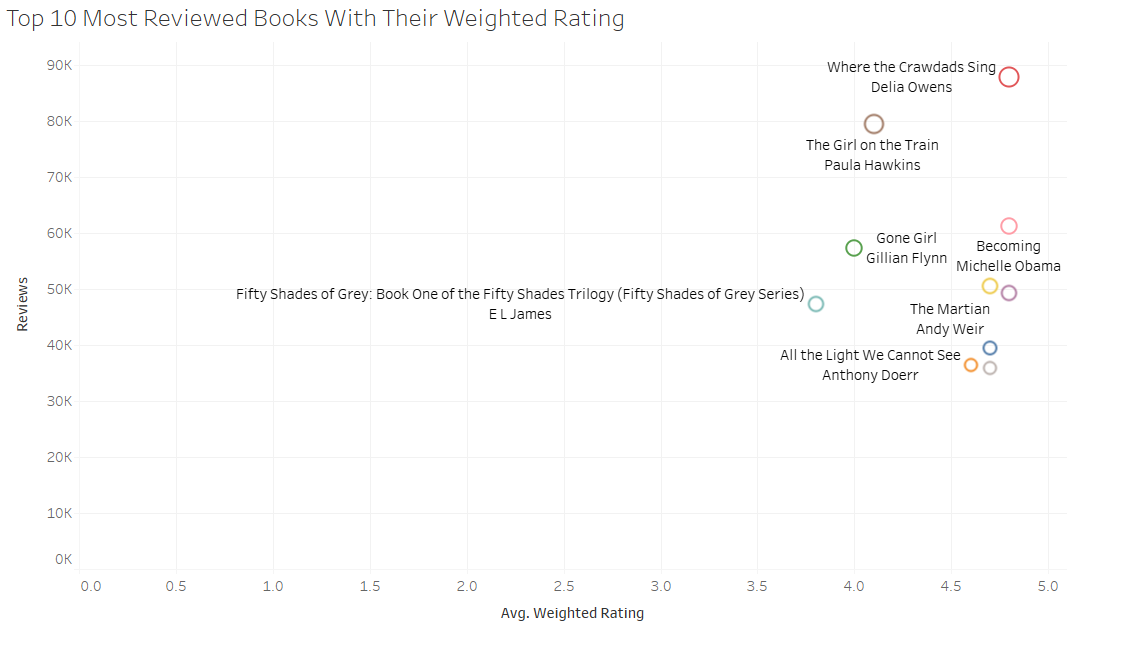

*Where The Crawdads Sing* by Delia Owens is the most well-reviewed and most reviewed book on the Bestseller List. 

*Becoming* by Michelle Obama is the most reviewed and highest-rated nonfiction book on the Bestseller list.

In [75]:
data.groupby(['Genre'])['Reviews'].mean()

Genre
Fiction        15683.791667
Non Fiction     9065.145161
Name: Reviews, dtype: float64

Fiction tends to be reviewed more in this case than non-fiction. This suggests that fiction readers tend to be more enthusiastic about reviewing books.

<h2><u>Trends Over Time</u></h2>

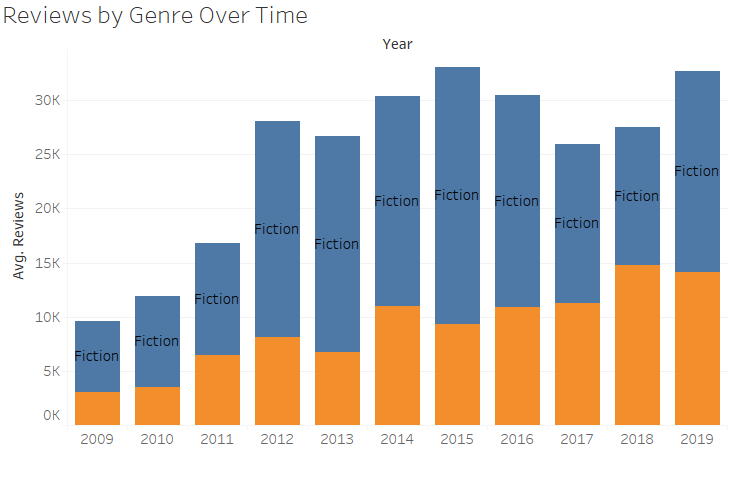

From 2009-2019, the share of reviews has trended towards a more even share between fiction and non-fiction. 

Total review count dipped in the years 2013, 2016, 2017, and 2018. 

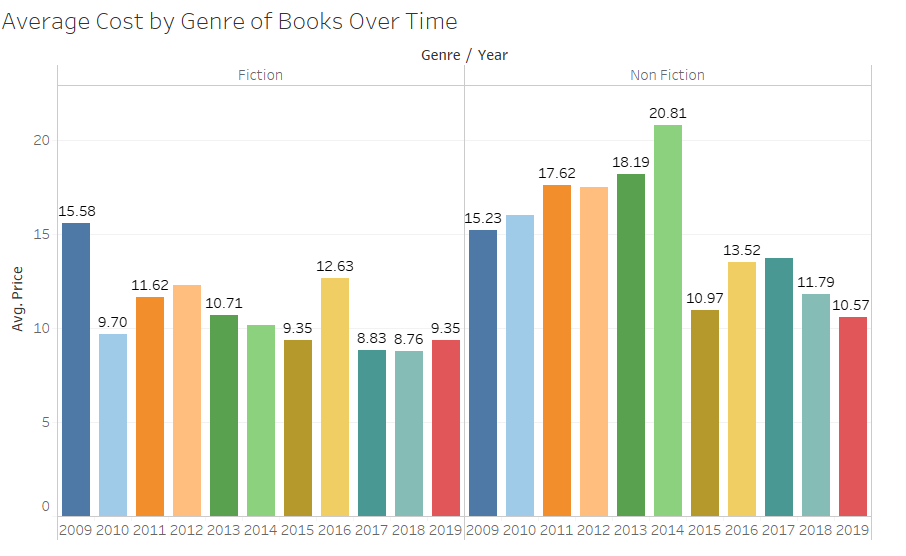

Fiction prices have remained relatively stable over time. However, in the case of non-fiction, prices have been more volatile. 

Overall, prices have decreased over the years. 

Prices were at their peak for non-fiction in 2014, and fiction in 2009. The cheapest years were 2018 and 2019 for fiction and non-fiction, respectively.

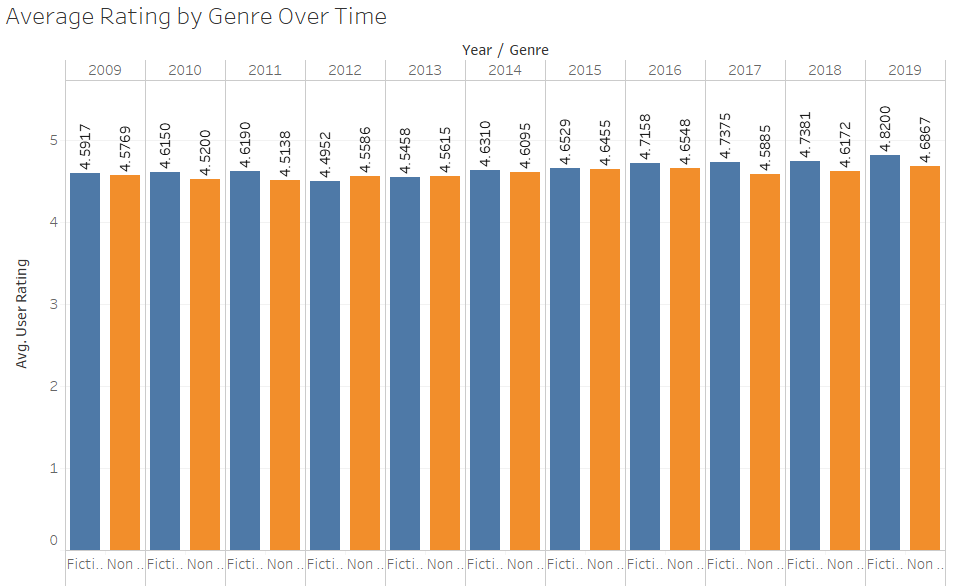

Ratings for fiction have steadily increased over time, while non-fiction has fluctuated. 

<h2><u>Conclusion</u></h2>

There were more non-fiction books on the bestselling list over the years and these non-fiction books were more expensive than their counterparts on average. 

However, fiction books are reviewed more and rated higher on average